In [1]:
# -*- coding: utf-8 -*-
"""
Created on Tue Sep 10 14:56:24 2024

@author: ulyss
"""

import random
import math
import pandas as pd
import copy
import os
import gurobipy as gb
from gurobipy import GRB
from itertools import chain, combinations, product, accumulate
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt
import hashlib
import copy
import time
import numpy as np
import multiprocessing
import queue

repertoire=r"C:\Users\ulyss\debut recherches"
os.chdir(repertoire)

In [2]:
def val_mnl(l):
    '''Return the MNL expected revenue for a list of revenue-weight alternatives.'''
    return sum([e[0]*e[2] for e in l])/(1+sum([e[2] for e in l]))

def opt_mnl_dichotomy(l): #useless
    '''Return an MNL revenue-ordered assortment using the retained dichotomy experiment.'''
    l.sort(reverse=True)
    a = 0
    b = len(l)
    while a + 2 <= b:
        m = (a+b) // 2
        r = val_mnl(l[:m])
        if l[m][0] < r:
            b = m
        else:
            a = m
    return [l[i][1] for i in range(a+1)], val_mnl(l[:(a+1)])

def opt_mnl(l): 
    '''Return an optimal MNL revenue-ordered assortment and its expected value.'''
    r=0
    S=[]
    weight=0
    i=0
    l.sort(reverse=True)
    while i<len(l) and l[i][0]>=r:
        r=(1+weight)/(1+weight+l[i][2]) * r + l[i][2]/(1+weight+l[i][2]) * l[i][0]
        S.append(l[i][1])
        weight+=l[i][2]
        i+=1

    return S, r

class BiGraph:
    """
    m = nb of left agents. n = nb of right agents.
    processed_left[i] = status of agent i. -2 = not processed yet, -1 = chose the exit option, j = chose j.
    left_values[i][j] = mnl value of agent j in the choice model of agent i
    left_backlogs[i] = list of backlogs of i
    matches = list of couple (i,j) who matched
    history = history of choices made. Useful for backtracking.
    """
    def __init__(self, m=0, n=0, v=[], w=[], mult=2, show=True):
        '''Initialize a two-sided MNL market and populate its customer and supplier data.'''
        self.m=0
        self.n=0
        self.processed_left=[]
        self.processed_right=[]
        self.left_values=[]
        self.right_values=[]
        self.left_backlogs=[]
        self.right_backlogs=[]
        self.matches=[]
        self.history=[]
        self.generate_instance(m, n, v, w, mult, show)
        
            
    def generate_instance(self, m, n, v, w, mult=2, show=True):
        '''Reset the graph dimensions and generate any missing agents with uniform weights.'''
        self.m = len(v)
        self.n = len(w)
        self.processed_left=[-2 for i in range(self.m)]
        self.processed_right=[-2 for j in range(self.n)]
        self.left_values=copy.deepcopy(v)
        self.right_values=copy.deepcopy(w)
        self.left_backlogs=[[] for i in range(self.m)]
        self.right_backlogs=[[] for j in range(self.n)]
        for i in range(m-self.m):
            self.add_customer([BiGraph.roll_distribution("unif0",mult) for j in range(self.n)], [BiGraph.roll_distribution("unif0",mult) for j in range(self.n)])
        for j in range(n-self.n):
            self.add_supplier([BiGraph.roll_distribution("unif0",mult) for i in range(self.m)], [BiGraph.roll_distribution("unif0",mult) for i in range(self.m)])
        if show and self.m+self.n<=8:
            self.show()

    def scale_instance(self, f):
        '''Multiply every customer and supplier preference weight by a common factor in place.'''
        for i in range(self.m):
            for j in range(self.n):
                self.left_values[i][j] *= f
                self.right_values[j][i] *= f
    
    def roll_distribution(name, p):
        '''Draw and round one preference weight from the named distribution specification.'''
        r=1
        if name=="exp":
           r= random.expovariate(p)
        elif name=="exp2":
            r = random.expovariate(p)**2
        elif name=="exp_tr":
            r = np.random.binomial(1, p[1]) * random.expovariate(p[0])
        elif name=="gamma":
            r= random.gammavariate(p[0], p[1])
        elif name=="norm":
            r= abs(random.normalvariate(p[0], p[1]))
        elif name=="unif0":
            r= random.random()*p
        elif name=="unif":
            r= p[0]+random.random()*(p[1]-p[0])
        elif name=="unif_tr":
            r = np.random.binomial(1, p[2]) * (p[0]+random.random()*(p[1]-p[0]))
        elif name=="const":
            r= p
        
        return round(r,2)
    
    def roll_instance(self, left="exp", right="exp", p_left=1, p_right=1, show=True):
        '''Replace all preference weights with independent draws from the requested distributions.'''
        self.reset()
        
        for i in range(self.m):
            for j in range(self.n):
                self.left_values[i][j]=BiGraph.roll_distribution(left, p_left)
                self.right_values[j][i]=BiGraph.roll_distribution(right, p_right)
        if show and self.m+self.n<=8:
            self.show()

    def roll_instance_staged_groups(self, nb=1, p = 1, v_min=0, v_max=1.6, show=False):
        '''Generate grouped preference profiles from staged uniform value intervals.'''
        self.reset()

        group_left = [[BiGraph.roll_distribution("unif", [v_min+k*(v_max-v_min)/nb, v_min+(k+1)*(v_max-v_min)/nb]) \
                       for _ in range(self.n)] for k in range(nb)]
        group_right = [[BiGraph.roll_distribution("unif", [v_min+k*(v_max-v_min)/nb, v_min+(k+1)*(v_max-v_min)/nb]) \
                       for _ in range(self.m)] for k in range(nb)]

        for i in range(self.m):
            g = np.random.randint(0,nb)
            self.left_values[i] = [np.random.binomial(1,p)*group_left[g][j] for j in range(self.n)]
        for j in range(self.n):
            g = np.random.randint(0,nb)
            self.right_values[j] = [np.random.binomial(1,p)*group_right[g][i] for i in range(self.m)]

        if show and self.m+self.n<=8:
            self.show()
        
    def roll_instance_groups(self, left="exp", right="exp", p_left=1, p_right=1, group_a = [1], group_b=1, show=False):
        '''Generate each side from a finite collection of randomly scaled preference profiles.'''
        self.reset()

        group_left = [[BiGraph.roll_distribution(left, p_left) for _ in range(self.n)] for _ in range(group_b)]
        group_right = [[BiGraph.roll_distribution(right, p_right) for _ in range(self.m)] for _ in range(group_b)]
        for b in range(group_b):
            a = group_a[np.random.randint(0,len(group_a))]
            group_left[b] = [a * v for v in group_left[b]]
            a = group_a[np.random.randint(0,len(group_a))]
            group_right[b] = [a * v for v in group_right[b]]
        
        for i in range(self.m):
            self.left_values[i] = copy.deepcopy(group_left[np.random.randint(0,group_b)])
    
        for j in range(self.n):
            self.right_values[j] = copy.deepcopy(group_right[np.random.randint(0,group_b)])
            
        if show and self.m+self.n <= 8:
            self.show()
    
    def roll_instance_homo(self, left="exp", right="exp", p_left=1, p_right=1, homo_left=0, homo_right = 0, show=True):
        '''Generate preference matrices with controllable probabilities of sharing common profiles.'''
        self.reset()

        common_left = [BiGraph.roll_distribution(left, p_left) for _ in range(self.n)]
        common_right = [BiGraph.roll_distribution(right, p_right) for _ in range(self.m)]
        for i in range(self.m):
            if np.random.random() < np.sqrt(homo_left):
                self.left_values[i] = common_left
            else:
                self.left_values[i] = [BiGraph.roll_distribution(left, p_left) for _ in range(self.n)]

        for j in range(self.n):
            if np.random.random() < np.sqrt(homo_right):
                self.right_values[j] = common_right
            else:
                self.right_values[j] = [BiGraph.roll_distribution(right, p_right) for _ in range(self.m)]

        if show and self.m+self.n<=8:
            self.show()
    
    def save_instance(self):
        '''Return a deep-copy snapshot of dimensions and both preference matrices.'''
        save = [self.m, self.n, copy.deepcopy(self.left_values), copy.deepcopy(self.right_values)]
        return save
    
    def reset(self):
        '''Clear choices, backlogs, matches, and history while preserving preference weights.'''
        self.processed_left=[-2 for i in range(self.m)]
        self.processed_right=[-2 for j in range(self.n)]
        self.left_backlogs=[[] for i in range(self.m)]
        self.right_backlogs=[[] for j in range(self.n)]
        self.matches=[]
        self.history=[]

    def symmetric(self):
        '''Exchange the customer and supplier sides of the market in place.'''
        self.reset()
        self.m, self.n=self.n, self.m
        self.processed_left, self.processed_right=self.processed_right, self.processed_left
        self.left_values, self.right_values=self.right_values, self.left_values
        self.left_backlogs, self.right_backlogs=self.right_backlogs, self.left_backlogs
    
    def show(self):
        '''Print dimensions, state, backlogs, matches, and both preference matrices.'''
        print("number of customers: ", self.m, "\nnumber of suppliers: ", self.n)
        print("matches:")
        for c in self.matches:
            print('(', c[0], '<->', c[1], end=') ')
        print("\ncustomers' backlogs:")
        
        for i in range(self.m):
            if self.processed_left[i]!=-2:
                continue
            print(i, end=' <- { ')
            for j in self.left_backlogs[i]:
                print(j, end = ' ')
            print('}')
        print("suppliers' backlogs:")
        
        for j in range(self.n):
            if self.processed_right[j]!=-2:
                continue
            
            print(j, end=' <- { ')
            for i in self.right_backlogs[j]:
                print(i, end =' ')
            print('}')
        
        print("v_ij (customers choose):")
        for i in range(self.m):
            print(i, end=' -> { ')
            for j in range(self.n):
                print(self.left_values[i][j], end=' ')
            print('}')
        print("w_ji (suppliers choose):")
        for j in range(self.n):
            print(j, end=' -> { ')
            for i in range(self.m):
                print(self.right_values[j][i], end=' ')
            print('}')

    def state_hash(self, show=False):
        '''Hash the decision-relevant processed and pending state for dynamic-programming memoization.'''
        s=""
        #s=f"{len(self.matches)},"
        for i in range(self.m):
            s+=f"{i}:"
            if self.processed_left[i]==-2:
                s+="r,"
            elif self.processed_left[i]==-1:
                s+="h,"
            elif self.processed_right[self.processed_left[i]]==-2:
                s+=f"p{self.processed_left[i]},"
            else:
                s+="h,"
        
        for j in range(self.n):
            s+=f"{j}:"
            if self.processed_right[j]==-2:
                s+="r,"
            elif self.processed_right[j]==-1:
                s+="h,"
            elif self.processed_left[self.processed_right[j]]==-2:
                s+=f"p{self.processed_right[j]},"
            else:
                s+="h,"
        if show:
            print(s)
        return hashlib.sha256(s.encode()).hexdigest()
            
    def add_customer(self, left, right):
        '''Append one customer and extend every supplier preference vector accordingly.'''
        self.m+=1
        self.processed_left.append(-2)
        self.left_values.append(list(left))
        self.left_backlogs.append([])
        for j in range(self.n):
            self.right_values[j].append(right[j])
    
    def add_supplier(self, left, right):
        '''Append one supplier and extend every customer preference vector accordingly.'''
        self.n+=1
        self.processed_right.append(-2)
        self.right_values.append(list(right))
        self.right_backlogs.append([])
        for i in range(self.m):
            self.left_values[i].append(left[i])
    
    def update_choice_customer(self, i, j):
        '''Record a customer choice, update the supplier backlog, and create a mutual match if applicable.'''
        self.processed_left[i]=j
        self.history.append(('c', i, j))
        if j>=0:
            self.right_backlogs[j].append(i)
            #print("customer ", i, " chooses supplier ", j)
            if self.processed_right[j]==i:
                self.match(i,j)
        else:
            #print("customer ", i, " exits")
            pass
        
    def update_choice_supplier(self, j, i):
        '''Record a supplier choice, update the customer backlog, and create a mutual match if applicable.'''
        self.processed_right[j]=i
        self.history.append(('s', i, j))
        if i>=0:
            self.left_backlogs[i].append(j)
            #print("supplier ", j, " chooses customer ", i)
            if self.processed_left[i]==j:
                self.match(i,j)
        else:
            #print("supplier ", j, " exits")
            pass
    
    def match(self, i, j):
        '''Record a mutual customer-supplier match in the state and undo history.'''
        self.history.append(('m', i, j))
        self.matches.append((i,j))
        #print("   customer ", i, " and supplier ", j, " match")
    
    def simulate_choice_customer(self, i, S):
        #print("customer ", i, " is offered assortment ", S)
        '''Sample one customer choice from the MNL distribution over a displayed assortment.'''
        thresholds=[1]
        for j in S:
            thresholds.append(thresholds[-1]+self.left_values[i][j])
        
        #print(thresholds)
        choice=random.random()*thresholds[-1]
        #print(choice)
        a, b = 0, len(thresholds)
        m = (a+b)//2
        while b-a > 1:
            if choice >= thresholds[m]:
                a = m+1
            if choice < thresholds[m]:
                if choice >= thresholds[m-1]:
                    self.update_choice_customer(i, S[m-1])
                    return
                b = m
            m = (a+b)//2
        
        if b==1:
            self.update_choice_customer(i, -1)
            return
        
        self.update_choice_customer(i, S[m-1])
    
    def simulate_choice_supplier(self, j, C):
        #print("supplier ", j, " is offered assortment ", C)
        '''Sample one supplier choice from the MNL distribution over a displayed assortment.'''
        thresholds=[1]
        for i in C:
            thresholds.append(thresholds[-1]+self.right_values[j][i])
        
        #(thresholds)
        choice=random.random()*thresholds[-1]
        #print(choice)
        a, b = 0, len(thresholds)
        m = (a+b)//2
        while b-a > 1:
            if choice >= thresholds[m]:
                a = m+1
            if choice < thresholds[m]:
                if choice >= thresholds[m-1]:
                    self.update_choice_supplier(j, C[m-1])
                    return
                b = m
            m = (a+b)//2
        
        if b==1:
            self.update_choice_supplier(j, -1)
            return
        
        self.update_choice_supplier(j, C[m-1])
        
    def undo(self, k=1):
        '''Undo the requested number of most recent state-changing actions.'''
        if k==0:
            return
        if len(self.history)==0:
            return
        a, i, j = self.history.pop()
        if a=='m':
            self.matches.pop()
            self.undo(k)
        if a=='c':
            self.processed_left[i]=-2
            if j>=0:
                self.right_backlogs[j].pop()
        if a=='s':
            self.processed_right[j]=-2
            if i>=0:
                self.left_backlogs[i].pop()
        self.undo(k-1)

In [3]:
l = [(np.random.random(), i, np.random.random()) for i in range(10**2)]
print("start")
t = time.time()
print(opt_mnl(l)[1])
print(time.time()-t)
t = time.time()
print(opt_mnl_dichotomy(l)[1])
print(time.time() - t)

start
0.8379441951517678
0.0010008811950683594
0.8379441951517678
0.0


In [14]:
b = BiGraph(5, 6)
b.roll_instance_groups(left="exp", right="exp", p_left=1, p_right=1, group_a = [1], group_b=2, show=False)
b.show()

#print(approx_xhigh(b), approx_xhigh_greedy(b))

number of customers:  5 
number of suppliers:  6
matches:

customers' backlogs:
0 <- { }
1 <- { }
2 <- { }
3 <- { }
4 <- { }
suppliers' backlogs:
0 <- { }
1 <- { }
2 <- { }
3 <- { }
4 <- { }
5 <- { }
v_ij (customers choose):
0 -> { 1.74 0.01 0.61 0.8 1.01 0.52 }
1 -> { 1.93 1.28 0.51 0.09 0.96 0.52 }
2 -> { 1.74 0.01 0.61 0.8 1.01 0.52 }
3 -> { 1.93 1.28 0.51 0.09 0.96 0.52 }
4 -> { 1.74 0.01 0.61 0.8 1.01 0.52 }
w_ji (suppliers choose):
0 -> { 0.09 0.46 2.31 0.32 1.4 }
1 -> { 1.09 1.89 0.63 0.08 0.84 }
2 -> { 0.09 0.46 2.31 0.32 1.4 }
3 -> { 0.09 0.46 2.31 0.32 1.4 }
4 -> { 0.09 0.46 2.31 0.32 1.4 }
5 -> { 0.09 0.46 2.31 0.32 1.4 }


In [3]:
def powerset(lst):
    '''Return all subsets of the supplied list as concrete lists.'''
    return [list(subset) for subset in chain.from_iterable(combinations(lst, r) for r in range(len(lst) + 1))]


def solve_fully_static(bigraph):
    '''Compute the exact Fully Static objective by enumerating every offered edge set.'''
    best = 0
    all_choices=powerset([(i,j) for i in range(bigraph.m) for j in range(bigraph.n)])  
    for subset in all_choices:
        weights_left=[0 for i in range(bigraph.m)]
        weights_right=[0 for j in range(bigraph.n)]
        r=0
        for edge in subset:
            weights_left[edge[0]]+=bigraph.left_values[edge[0]][edge[1]]
            weights_right[edge[1]]+=bigraph.right_values[edge[1]][edge[0]]
            
        r=sum([(bigraph.left_values[edge[0]][edge[1]])/(1+weights_left[edge[0]])\
               *bigraph.right_values[edge[1]][edge[0]]/(1+weights_right[edge[1]]) for edge in subset])
        best = max(best, r)
    
    return best

def solve_one_sided_static_c(bigraph):
    '''Compute the exact customer-initiated One-sided Static value by exhaustive enumeration.'''
    best = 0
    pw=powerset([j for j in range(-1, bigraph.n)])
    all_choices=[]
    for subset in pw:
            if len(subset)>0 and subset[0]==-1:
                all_choices.append(subset)
    for subset in product(all_choices, repeat=bigraph.m):
        r = 0 
        weights_left=[sum([bigraph.left_values[i][j] for j in subset[i] if j>=0]) for i in range(bigraph.m)]
        
        for choices in product(*subset):
            p=1
            for i in range(bigraph.m):
                bigraph.update_choice_customer(i, choices[i])
                if choices[i]==-1:
                    p*=1/(1+weights_left[i])
                else:
                    p*=bigraph.left_values[i][choices[i]]/(1+weights_left[i])
            
            weights_right=[sum([bigraph.right_values[j][i] for i in bigraph.right_backlogs[j]])\
                           for j in range(bigraph.n)]    
            r += p*sum([weights_right[j]/(1+weights_right[j]) for j in range(bigraph.n)])
            bigraph.reset()
        best = max(best, r)
    
    return best

def solve_one_sided_static(bigraph):
    '''Compute both initiating-side One-sided Static optima and return the better value.'''
    r1= solve_one_sided_static_c(bigraph) 
    bigraph.symmetric()
    r2=solve_one_sided_static_c(bigraph)
    bigraph.symmetric()
    print("OS", r1, r2)
    return max(r1,r2)

def solve_one_sided_adaptive_c_rec(bigraph, remaining, all_choices, best):
    '''Recursively solve customer-initiated One-sided Adaptive by enumerating assortments and outcomes.'''
    if len(remaining)==0:
        #print(bigraph.history)
        global a
        a+= 1
        weights=[sum([bigraph.right_values[j][i] for i in bigraph.right_backlogs[j]]) for j in range(bigraph.n)]
        return sum([weights[j]/(1+weights[j]) for j in range(bigraph.n)])

    for i in remaining:
        remaining.remove(i)
        for subset in all_choices:
            if len(subset)==0:
                continue
            bigraph.update_choice_customer(i,-1)
            r = solve_one_sided_adaptive_c_rec(bigraph, remaining, all_choices, 0)
            bigraph.undo()
            for j in subset:
                bigraph.update_choice_customer(i, j)
                r += bigraph.left_values[i][j]*solve_one_sided_adaptive_c_rec(bigraph, remaining, all_choices, 0)
                bigraph.undo()
            
            weight = 1+sum([bigraph.left_values[i][j] for j in subset])
            best=max(best, r/weight)
        remaining.insert(0,i)
    
    return best

def solve_one_sided_adaptive_c_rec_hash_mnl(bigraph, remaining, dic, best):
    '''Solve the customer-initiated MNL adaptive recursion using state memoization and MNL assortment optimization.'''
    global a
    global d
    key=bigraph.state_hash()
    if key in dic:
        d+=1
        return dic[key]
        
    if len(remaining)==0:
        a+= 1
        weights=[sum([bigraph.right_values[j][i] for i in bigraph.right_backlogs[j]]) for j in range(bigraph.n)]
        r = sum([weights[j]/(1+weights[j]) for j in range(bigraph.n)])
        dic[key]=r
        return r

    for k,i in enumerate(remaining):
        remaining.remove(i)
        bigraph.update_choice_customer(i,-1)
        r0=solve_one_sided_adaptive_c_rec_hash_mnl(bigraph, remaining, dic, 0)
        #le,ri,d=copy.deepcopy(remaining_left), copy.deepcopy(remaining_right), copy.deepcopy(dic)
        #r2=solve_fully_adaptive_rec_hash(bigraph, le, ri, d,0)
        #print(bigraph.history)
        #print("r c 0 ", r0,r2)
        bigraph.undo()
        l=[]
        for j in range(bigraph.n):
            bigraph.update_choice_customer(i,j)
            rj=solve_one_sided_adaptive_c_rec_hash_mnl(bigraph, remaining, dic, 0)    
            bigraph.undo()
            l.append((rj-r0,j,bigraph.left_values[i][j]))
        
        _, r = opt_mnl(l)
        r+=r0

        best=max(best,r)
        remaining.insert(k,i)
    dic[key]=best
    return best


def solve_one_sided_adaptive(bigraph):
    '''Compute the exhaustive One-sided Adaptive value for each initiating side and return the maximum.'''
    global a
    a=0
    bigraph.reset()
    all_choices = powerset([j for j in range(bigraph.n)])
    t=time.time()
    r1=solve_one_sided_adaptive_c_rec(bigraph, [i for i in range(bigraph.m)], all_choices, 0)
    bigraph.symmetric()
    all_choices = powerset([j for j in range(bigraph.n)])
    r2=solve_one_sided_adaptive_c_rec(bigraph, [j for j in range(bigraph.m)], all_choices, 0)
    bigraph.symmetric()
    print("t ", time.time()-t)
    #print("OA", r1, r2)
    return max(r1, r2)

def solve_one_sided_adaptive_hash_mnl(bigraph):
    '''Compute the memoized MNL One-sided Adaptive value for both initiating sides.'''
    global a
    a=0
    global d
    d = 0
    bigraph.reset()
    r1=solve_one_sided_adaptive_c_rec_hash_mnl(bigraph, [i for i in range(bigraph.m)], {}, 0)
    bigraph.symmetric()
    r2=solve_one_sided_adaptive_c_rec_hash_mnl(bigraph, [j for j in range(bigraph.m)], {}, 0)
    bigraph.symmetric()
    #print("OA", r1, r2)
    return max(r1, r2)

def e(m,n):
    '''Retain the unimplemented exploratory state-count placeholder.'''
    pass
def f(m,n):
    '''Estimate One-sided Adaptive exhaustive-search tree sizes for both initiating sides.'''
    r1, r2= math.factorial(m)*(n*2**(n-1)+2**n)**m, math.factorial(n)*(m*2**(m-1)+2**m)**n
    return r1, r2, r1+r2, math.log10(r1+r2)

def g(m,n):
    #g(3,3) environ 33hrs
    '''Estimate the Fully Adaptive exhaustive-search tree size.'''
    r= math.factorial(m+n)*(n*2**(n-1)+2**n)**m * (m*2**(m-1)+2**m)**n
    return r, math.log10(r)


def solve_fully_adaptive_rec_naive(bigraph, remaining_left, remaining_right, best):
    '''Recursively solve Fully Adaptive by exhaustively enumerating agents, assortments, and outcomes.'''
    if len(remaining_left)+len(remaining_right) == 0:
        global a
        a+=1
        #print(bigraph.history)
        #if random.random() < 10**5/24576000:
            #print(a/24576000)
        return len(bigraph.matches)
    if len(remaining_left)+len(remaining_right)==5:
        global c
        c+=1
        print(c)
        print(remaining_left, remaining_right)
        
    all_choices = powerset(remaining_right)
    
    for i in remaining_left:
        remaining_left.remove(i)
        for subset in all_choices:
            bigraph.update_choice_customer(i,-1)
            r = solve_fully_adaptive_rec_naive(bigraph, remaining_left, remaining_right, 0)
            bigraph.undo()
            
            for j in bigraph.left_backlogs[i]:    
                bigraph.update_choice_customer(i,j)
                r+=bigraph.left_values[i][j]*solve_fully_adaptive_rec_naive(bigraph, remaining_left, remaining_right, 0)
                bigraph.undo()
            for j in subset:    
                bigraph.update_choice_customer(i,j)
                r+=bigraph.left_values[i][j]*solve_fully_adaptive_rec_naive(bigraph, remaining_left, remaining_right, 0)
                bigraph.undo()
                
            weight = 1 + sum([bigraph.left_values[i][j] for j in bigraph.left_backlogs[i]])+sum([bigraph.left_values[i][j] for j in subset])
            best = max(best, r/weight)
        
        remaining_left.insert(0,i)

    all_choices = powerset(remaining_left)
    for j in remaining_right:
        remaining_right.remove(j)
        for subset in all_choices:
            bigraph.update_choice_supplier(j,-1)
            r = solve_fully_adaptive_rec_naive(bigraph, remaining_left, remaining_right, 0)
            bigraph.undo()

            for i in bigraph.right_backlogs[j]:
                bigraph.update_choice_supplier(j,i)
                r+=bigraph.right_values[j][i]*solve_fully_adaptive_rec_naive(bigraph, \
                                                                remaining_left, remaining_right, 0)
                bigraph.undo()
                
            for i in subset:
                bigraph.update_choice_supplier(j,i)
                r+=bigraph.right_values[j][i]*solve_fully_adaptive_rec_naive(bigraph, \
                                                                remaining_left, remaining_right, 0)
                bigraph.undo()
            
            weight = 1 +  sum([bigraph.right_values[j][i] for i in bigraph.right_backlogs[j]])+sum([bigraph.right_values[j][i] for i in subset])
            best = max(best, r/weight)
            
        remaining_right.insert(0,j)
    
    return best

def solve_fully_adaptive_rec(bigraph, remaining_left, remaining_right, best):
    '''Recursively solve Fully Adaptive while caching repeated outcome evaluations within each state.'''
    if len(remaining_left)+len(remaining_right) == 0:
        global a
        a+=1
        #if random.random() < 10**5/24576000:
            #print(a/24576000)
        return len(bigraph.matches)
        
    all_choices = powerset(remaining_right)
    
    for k, i in enumerate(remaining_left):
        d=0
        
        remaining_left.remove(i)
        stored = [-1 for j in range(bigraph.n+1)]
        for subset in all_choices:
            if stored[bigraph.n]==-1:
                bigraph.update_choice_customer(i,-1)
                v = solve_fully_adaptive_rec(bigraph, remaining_left, remaining_right, 0)
                stored[bigraph.n]=v
                bigraph.undo()
            r=stored[bigraph.n]

            for j in bigraph.left_backlogs[i]+subset:
                if stored[j]==-1:
                    bigraph.update_choice_customer(i,j)
                    v=solve_fully_adaptive_rec(bigraph, remaining_left, remaining_right, 0)
                    stored[j]=v
                    bigraph.undo()
                r+= bigraph.left_values[i][j]*stored[j]
                
            weight = 1 + sum([bigraph.left_values[i][j] for j in bigraph.left_backlogs[i]+subset])
            best = max(best, r/weight)
            d=max(d,r/weight)
        remaining_left.insert(k,i)

    all_choices = powerset(remaining_left)
    
    for k, j in enumerate(remaining_right):
        d=0
        
        remaining_right.remove(j)
        stored = [-1 for j in range(bigraph.m+1)]
        for subset in all_choices:
            if stored[bigraph.m]==-1:
                bigraph.update_choice_supplier(j,-1)
                v = solve_fully_adaptive_rec(bigraph, remaining_left, remaining_right, 0)
                stored[bigraph.m]=v
                bigraph.undo()
            r=stored[bigraph.m]

            for i in bigraph.right_backlogs[j]+subset:
                if stored[i]==-1:
                    bigraph.update_choice_supplier(j,i)
                    v=solve_fully_adaptive_rec(bigraph, remaining_left, remaining_right, 0)
                    stored[i]=v
                    bigraph.undo()
                r+=bigraph.right_values[j][i]*stored[i]
            
            weight = 1 +  sum([bigraph.right_values[j][i] for i in bigraph.right_backlogs[j]+subset])
            best = max(best, r/weight)
            d=max(d,r/weight)
        remaining_right.insert(k,j)
    
    return best

def solve_fully_adaptive_rec_hash(bigraph, remaining_left, remaining_right, dic, best):
    '''Recursively solve Fully Adaptive with memoization of decision-relevant graph states.'''
    global a
    global d
    key=bigraph.state_hash()
    if key in dic:
        d+=1
        return len(bigraph.matches)+dic[key]
    
    if len(remaining_left) == 0 or len(remaining_right)==0:
        a+=1
        weights_left=[sum([bigraph.left_values[i][j] for j in bigraph.left_backlogs[i]]) for i in remaining_left]
        weights_right=[sum([bigraph.right_values[j][i] for i in bigraph.right_backlogs[j]]) for j in remaining_right]
        r= len(bigraph.matches)+sum([w/(1+w) for w in weights_left+weights_right])
        dic[key]=r-len(bigraph.matches)
        return r
        
    all_choices = powerset(remaining_right)
    for k,i in enumerate(remaining_left):
        remaining_left.remove(i)
        stored = [-1 for j in range(bigraph.n+1)]
        for subset in all_choices:
            if stored[bigraph.n]==-1:
                bigraph.update_choice_customer(i,-1)
                v = solve_fully_adaptive_rec_hash(bigraph, remaining_left, remaining_right, dic, 0)
                stored[bigraph.n]=v
                bigraph.undo()
            r=stored[bigraph.n]

            for j in bigraph.left_backlogs[i]+subset:
                if stored[j]==-1:
                    bigraph.update_choice_customer(i,j)
                    v=solve_fully_adaptive_rec_hash(bigraph, remaining_left, remaining_right, dic, 0)
                    stored[j]=v
                    bigraph.undo()
                r+= bigraph.left_values[i][j]*stored[j]
                
            weight = 1 + sum([bigraph.left_values[i][j] for j in bigraph.left_backlogs[i]+subset])
            best = max(best, r/weight)
        remaining_left.insert(k,i)

    all_choices = powerset(remaining_left)
    for k,j in enumerate(remaining_right):
        remaining_right.remove(j)
        stored = [-1 for j in range(bigraph.m+1)]
        for subset in all_choices:
            if stored[bigraph.m]==-1:
                bigraph.update_choice_supplier(j,-1)
                v = solve_fully_adaptive_rec_hash(bigraph, remaining_left, remaining_right, dic, 0)
                stored[bigraph.m]=v
                bigraph.undo()
            r=stored[bigraph.m]

            for i in bigraph.right_backlogs[j]+subset:
                if stored[i]==-1:
                    bigraph.update_choice_supplier(j,i)
                    v=solve_fully_adaptive_rec_hash(bigraph, remaining_left, remaining_right, dic, 0)
                    stored[i]=v
                    bigraph.undo()
                r+=bigraph.right_values[j][i]*stored[i]
            
            weight = 1 +  sum([bigraph.right_values[j][i] for i in bigraph.right_backlogs[j]+subset])
            best = max(best, r/weight)
        remaining_right.insert(k,j)

    dic[key]=best-len(bigraph.matches)
    return best

def solve_fully_adaptive_rec_hash_mnl(bigraph, remaining_left, remaining_right, dic, best):
    '''Solve the Fully Adaptive MNL recursion using memoization and revenue-ordered assortment optimization.'''
    key=bigraph.state_hash()
    global a
    global d
    if key in dic:
        d+=1
        return len(bigraph.matches)+dic[key]
    
    if len(remaining_left) == 0 or len(remaining_right)==0:
        a+=1
        weights_left=[sum([bigraph.left_values[i][j] for j in bigraph.left_backlogs[i]]) for i in remaining_left]
        weights_right=[sum([bigraph.right_values[j][i] for i in bigraph.right_backlogs[j]]) for j in remaining_right]
        r= len(bigraph.matches)+sum([w/(1+w) for w in weights_left+weights_right])
        dic[key]=r-len(bigraph.matches)
        return r
        
    for k,i in enumerate(remaining_left):
        remaining_left.remove(i)
        bigraph.update_choice_customer(i,-1)
        r0=solve_fully_adaptive_rec_hash_mnl(bigraph, remaining_left, remaining_right, dic, 0)
        #le,ri,d=copy.deepcopy(remaining_left), copy.deepcopy(remaining_right), copy.deepcopy(dic)
        #r2=solve_fully_adaptive_rec_hash(bigraph, le, ri, d,0)
        #print(bigraph.history)
        #print("r c 0 ", r0,r2)
        bigraph.undo()
        l=[(1,'b',sum([bigraph.left_values[i][j] for j in bigraph.left_backlogs[i]]))]
        for j in remaining_right:
            bigraph.update_choice_customer(i,j)
            rj=solve_fully_adaptive_rec_hash_mnl(bigraph, remaining_left,remaining_right, dic, 0)    
            bigraph.undo()
            l.append((rj-r0,j,bigraph.left_values[i][j]))
        
        _, r = opt_mnl(l)
        r+=r0

        best=max(best,r)
        remaining_left.insert(k,i)

    for k,j in enumerate(remaining_right):
        remaining_right.remove(j)
        bigraph.update_choice_supplier(j,-1)
        r0=solve_fully_adaptive_rec_hash_mnl(bigraph, remaining_left, remaining_right, dic, 0)
        #le,ri,d=copy.deepcopy(remaining_left), copy.deepcopy(remaining_right), copy.deepcopy(dic)
        #r2=solve_fully_adaptive_rec_hash(bigraph, le, ri, d,0)
        #print(bigraph.history)
        #print("r s 0 ", r0,r2)
        bigraph.undo()
        l=[(1,'b',sum([bigraph.right_values[j][i] for i in bigraph.right_backlogs[j]]))]
        for i in remaining_left:
            bigraph.update_choice_supplier(j,i)
            ri=solve_fully_adaptive_rec_hash_mnl(bigraph, remaining_left,remaining_right, dic, 0)
            bigraph.undo()
            l.append((ri-r0,i,bigraph.right_values[j][i]))
        
        _, r = opt_mnl(l)
        r+=r0
        best=max(best,r)
        remaining_right.insert(k,j)  

    dic[key]=best-len(bigraph.matches)
    return best

def solve_fully_adaptive(bigraph):
    '''Reset the graph and run the non-memoized optimized Fully Adaptive recursion.'''
    global a
    a=0
    bigraph.reset()
    return solve_fully_adaptive_rec(bigraph, [i for i in range(bigraph.m)], [j for j in range(bigraph.n)], 0)

def solve_fully_adaptive_naive(bigraph):
    '''Reset the graph and run the naive Fully Adaptive recursion.'''
    global a
    a=0
    bigraph.reset()
    return solve_fully_adaptive_rec_naive(bigraph, [i for i in range(bigraph.m)], [j for j in range(bigraph.n)], 0)

def solve_fully_adaptive_hash(bigraph):
    '''Reset the graph, run the memoized Fully Adaptive recursion, and report its runtime.'''
    global a
    global d
    a =0
    d=0
    bigraph.reset()
    t=time.time()
    r= solve_fully_adaptive_rec_hash(bigraph, [i for i in range(bigraph.m)], [j for j in range(bigraph.n)], {}, 0)
    print("t ", time.time()-t)
    return r
def solve_fully_adaptive_hash_mnl(bigraph):

    '''Reset the graph and run the memoized MNL Fully Adaptive dynamic program.'''
    global a
    global d
    a =0
    d=0
    bigraph.reset()
    r= solve_fully_adaptive_rec_hash_mnl(bigraph, [i for i in range(bigraph.m)], [j for j in range(bigraph.n)], {}, 0)
    return r

In [4]:
def exact_fully_static(b, prec=0.05, time=7200, K=0, show=1):
    '''Solve the Appendix F.1.1 nonconvex bilinear Fully Static formulation and return its objective bound.'''
    model = gb.Model('bilinear')
    model.setParam('OutputFlag', show)
    y=[[] for i in range(b.m)]
    z=[[] for j in range(b.n)]
    y=[[model.addVar(lb=0,ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name=f'y_{i}{j}') for j in range(b.n)] for i in range(b.m)]
    z=[[model.addVar(lb=0,ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name=f'z_{j}{i}') for i in range(b.m)] for j in range(b.n)]
    for i in range(b.m):
        for j in range(b.n):
            model.addConstr(y[i][j]  <= b.left_values[i][j]*(1 - gb.quicksum(y[i]) ))
            model.addConstr(z[j][i] <= b.right_values[j][i]*(1 - gb.quicksum(z[j]) ))
    if K:
        for i in range(b.m):
            model.addConstr(gb.quicksum([y[i][j]/b.left_values[i][j] for j in range(b.n)])<=K*(1 - gb.quicksum(y[i])))
        for j in range(b.n):
            model.addConstr(gb.quicksum([z[j][i]/b.right_values[j][i] for i in range(b.m)])<=K*(1-gb.quicksum(z[j])))
            
    model.setObjective(gb.quicksum([y[i][j]*z[j][i] for i in range(b.m) for j in range(b.n)]), GRB.MAXIMIZE)
    model.setParam('nonconvex',2)
    model.setParam('MIPGap', prec)
    model.setParam('TimeLimit', time)
    model.optimize()

    return model.objBoundC#, [[y[i][j].x for j in range(b.n)] for i in range(b.m)], [[z[j][i].x for i in range(b.m)] for j in range(b.n)]
        

In [6]:
def upper_bound_oa_fw(b): #MNL Frank-Wolfe
    '''Approximate the customer-initiated One-sided Adaptive upper bound with the retained Frank-Wolfe routine.'''
    z = np.array([0 for j in range(b.n)])
    W = sum([(sum([b.right_values[j][i] for i in range(b.m)]))**2 for j in range(b.n)])
    size = np.sqrt(max(b.m,b.n)*W)
    T = 10**3 *max(10, int(size))
    t = 0
    change=0
    g_z1 = 0
    print(T)
    while t < T:
        if random.random()<0.01:
            #print(t/T)
            pass
        S=[]
        weights_left=[]
        delta_g = np.array([1/(1+z[j])**2 for j in range(b.n)])
        for i in range(b.m):
            l =[(delta_g[j], j, b.left_values[i][j]) for j in range(b.n)]
            Si, _ = opt_mnl(l)
            S.append(Si)
            weights_left.append(sum([b.left_values[i][j] for j in Si]))
            
        w = np.array([sum([b.right_values[j][i]*b.left_values[i][j]/(1+weights_left[i]) for i in range(b.m) if j in S[i]]) for j in range(b.n)])
        gamma = min(1, np.dot(delta_g, w)/ (2*size))
        
        z = (1-gamma)*z + gamma*w
        g_z2 =sum([z[j]/(1+z[j]) for j in range(b.n)])
        change = abs((g_z2-g_z1)/g_z2)
        g_z1 = g_z2
        #print(change)
        t+=1
        
    return sum([z[j]/(1+z[j]) for j in range(b.n)])

In [7]:
def upper_bound_oa_c(b):
    '''Solve the Appendix F.1.2 concave upper bound for customer-initiated One-sided Adaptive.'''
    z=cp.Variable(b.n)
    y=cp.Variable((b.m,b.n+1))
    
    constraints=[z>=0,y>=0]
    
    for i in range(b.m):
        constraints.append(y[i][b.n]+cp.sum([y[i][j]*b.left_values[i][j] for j in range(b.n)]) <= 1)
        for j in range(b.n):
            constraints.append(y[i][j] <= y[i][b.n])

    for j in range(b.n):
        constraints.append(z[j] <= cp.sum([b.left_values[i][j]*b.right_values[j][i]*y[i][j] for i in range(b.m)]))
        
    objective=cp.Maximize(cp.sum([1-cp.inv_pos(1+z[j]) for j in range(b.n)]))
    
    pb = cp.Problem(objective, constraints)
    pb.solve()

    r = pb.value
    
    return r

def upper_bound_oa(b):
    '''Solve the One-sided Adaptive upper bound from each initiating side and return the larger value.'''
    r1 = upper_bound_oa_c(b)
    b.symmetric()
    r2 = upper_bound_oa_c(b)
    b.symmetric  #for agent to fix: call b.symmetric() to restore the original orientation
    return max(r1,r2)

In [8]:
def value_fs(b, x):
    '''Evaluate the expected Fully Static number of matches for a binary offered-edge matrix.'''
    weights_left=[sum([b.left_values[i][j] for j in range(b.n) if x[i][j]]) for i in range(b.m)]
    weights_right=[sum([b.right_values[j][i] for i in range(b.m) if x[i][j]]) for j in range(b.n)]
            
    r=sum([b.left_values[i][j]/(1+weights_left[i])*b.right_values[j][i]/(1+weights_right[j])\
           for i in range(b.m) for j in range(b.n) if x[i][j]])
    return r

def approx_lowlow(b, rep=50, prec=0.02, time=120, show=0):
    '''Solve the low-low linear relaxation and average independently rounded Fully Static solutions.'''
    model = gb.Model('relaxation')
    model.setParam('OutputFlag', show)
    y=[[model.addVar(lb=0,ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name=f'y_{i}{j}') for j in range(b.n+1)] for i in range(b.m+1)]
    for i in range(b.m):
        model.addConstr(y[i][b.n]+gb.quicksum([b.right_values[j][i]*y[i][j] for j in range(b.n)])<=1)
    for j in range(b.n):
        model.addConstr(y[b.m][j]+gb.quicksum([b.left_values[i][j]*y[i][j] for i in range(b.m)])<=1)
    for i in range(b.m):
        for j in range(b.n):
            model.addConstr(y[i][j]<=y[b.m][j])
            model.addConstr(y[i][j]<=y[i][b.n])

    model.setObjective(gb.quicksum([b.left_values[i][j]*b.right_values[j][i]*y[i][j] for i in range(b.m) for j in range(b.n)]), GRB.MAXIMIZE)
    model.setParam('MIPGap', prec)
    #model.setParam('TimeLimit', time)
    model.optimize()

    r=0
    #print([[y[i][j].x for j in range(b.n)] for i in range(b.m)])
    for k in range(rep):
        x=[[random.random()<=y[i][j].x for j in range(b.n)] for i in range(b.m)]
        #r = max(r,value_fs(b,x)) #max or average ???
        r += value_fs(b,x)
    #return r
    return r/rep

def approx_xhigh_greedy(b, rep=20): #rep is useless
    '''Construct a high-value-regime Fully Static solution with the retained marginal greedy assignment.'''
    weights = [0 for _ in range(b.n)]
    x = [[0 for j in range(b.n)] for i in range(b.m)]
    for i in range(b.m):
        max_val = 0
        argmax = 0
        for j in range(b.n):
            if (b.left_values[i][j] == 0):
                continue
            val = (weights[j] + b.right_values[j][i]) / (1+weights[j] + b.right_values[j][i]) - weights[j] / (1+weights[j])
            if val > max_val:
                max_val = val
                argmax = j
        weights[argmax] += b.right_values[argmax][i]
        x[i][argmax] = 1
    return value_fs(b, x)

def approx_xhigh(b, rep=20, prec=0.02, time=120):
    '''Solve the retained concave high-value relaxation and average randomized assignments.'''
    y=cp.Variable((b.m,b.n))
    constraints=[y>=0]
    for i in range(b.m):
        constraints.append(cp.sum(y[i])<=1)
    objective=cp.Maximize(cp.sum([1-1*cp.inv_pos(1+cp.sum([y[i][j]*b.right_values[j][i] for i in range(b.m)])) for j in range(b.n)]))
    pb = cp.Problem(objective, constraints)
    pb.solve()

    r=0
    for k in range(rep):
        x=[[False for j in range(b.n)] for i in range(b.m)]
        for i in range(b.m):
            weights=list(accumulate([y[i][j].value for j in range(b.n)]))
            if weights[-1]<=0.:
                continue
            c = random.random()*weights[-1]
            a, d = 0, len(weights)
            m = (a+d)//2
            while d-a > 1:
                if c >= weights[m]:
                    a = m+1
                if c < weights[m]:
                    if c >= weights[m-1]:
                        break
                    d = m
                m = (a+d)//2
                
            x[i][m]=True

        #r = max(r,value_fs(b,x)) #max or average?
        r += value_fs(b,x)
    #return r
    return r/rep

def approx_fully_static(b, rep=50):
    '''Partition edges by the fixed alpha threshold and return the best retained regime algorithm.'''
    alpha=math.sqrt(5)/2-1/2
    bll,bxh,bhl=BiGraph(b.m,b.n,mult=0, show=False),BiGraph(b.m,b.n,mult=0, show=False),BiGraph(b.m,b.n,mult=0, show=False)
    for i in range(b.m):
        for j in range(b.n):
            v, w = b.left_values[i][j], b.right_values[j][i]
            if v<alpha:
                if w<alpha:
                    bll.left_values[i][j],bll.right_values[j][i]=v, w
                else:
                    bhl.left_values[i][j],bhl.right_values[j][i]=v, w
            else:
                bxh.left_values[i][j],bxh.right_values[j][i]=v, w
    bhl.symmetric()
    
    rll = approx_lowlow(bll,rep)
    rxh=approx_xhigh_greedy(bxh,rep)
    bhl.symmetric()  #for agent to fix: this second call undoes the intended side exchange before the high-value greedy step
    rhl=approx_xhigh_greedy(bhl,rep)
    #print(rll, rxh, rhl)
    return max(rll, rxh, rhl)

In [9]:
b = BiGraph(10, 10)

b.roll_instance_groups("exp_tr", "exp_tr", [0.00001, 0.5], [0.00001, 0.5], [1], 10)

r = approx_xhigh_greedy(b)
s = adaptive_greedy(b)
print(r, s)

NameError: name 'adaptive_greedy' is not defined

In [9]:
def naive_fs(b):
    '''Evaluate the Fully Static policy that displays every possible edge.'''
    x = [[1 for j in range(b.n)] for i in range(b.m)]
    return value_fs(b, x)

In [11]:
b = BiGraph(10, 10)
#b.roll_instance_homo("const", "const", 10**4, 10**4, show=False)

b.roll_instance_homo(show=False)

print(approx_xhigh(b), approx_xhigh_greedy(b))

2.1393216627701177 2.692631022779273


In [10]:
def solve_fully_static_K(bigraph, K=0):
    '''Compute the exact Fully Static value with a common cardinality limit by edge-set enumeration.'''
    if K==0:
        K=max(bigraph.m,bigraph.n)
    best = 0
    all_choices=powerset([(i,j) for i in range(bigraph.m) for j in range(bigraph.n)])  
    for subset in all_choices:
        weights_left=[0 for i in range(bigraph.m)]
        weights_right=[0 for j in range(bigraph.n)]
        c_left=[0 for i in range(bigraph.m)]
        c_right=[0 for j in range(bigraph.n)]
        r=0
        out =False
        for edge in subset:
            i,j=edge
            weights_left[i]+=bigraph.left_values[i][j]
            c_left[i]+=1
            weights_right[j]+=bigraph.right_values[j][i]
            c_right[j]+=1
            if c_left[i]>K or c_right[j]>K:
                out=True
                break

        if out:
            continue
        
        r=sum([(bigraph.left_values[i][j])/(1+weights_left[i])*bigraph.right_values[j][i]/(1+weights_right[j]) for i,j in subset])
        best = max(best, r)
    
    return best

In [11]:
def value_os(b, subset):
    '''Compute the exact customer-initiated One-sided Static value for fixed assortments.'''
    r = 0
    weights_left=[sum([b.left_values[i][j] for j in subset[i] if j>=0]) for i in range(b.m)]
        
    for choices in product(*subset):
        p=1
        for i in range(b.m):
            b.update_choice_customer(i, choices[i])
            if choices[i]==-1:
                p*=1/(1+weights_left[i])
            else:
                p*=b.left_values[i][choices[i]]/(1+weights_left[i])
            
        weights_right=[sum([b.right_values[j][i] for i in b.right_backlogs[j]])\
                       for j in range(b.n)]    
        r += p*sum([weights_right[j]/(1+weights_right[j]) for j in range(b.n)])
        b.reset()

    return r

def estimate_value_os(b, subset, rep=50):
    '''Estimate a fixed customer-initiated One-sided Static policy by Monte Carlo simulation.'''
    r=0
    for i in range(b.m):
        subset[i].pop()
    for k in range(rep):
        for i in range(b.m):
            b.simulate_choice_customer(i, subset[i])
        
        weights=[sum([b.right_values[j][i] for i in b.right_backlogs[j]]) for j in range(b.n)]
        r0= sum([weights[j]/(1+weights[j]) for j in range(b.n)])
        #print(r0)
        r+= r0
        b.reset()
    return r/rep

def random_order_greedy_c(b):
    '''Construct and evaluate the customer-initiated static benchmark using simulated random-order greedy.'''
    subset=[[] for i in range(b.m)]
    weights_right=[0 for j in range(b.n)]

    list_i=[i for i in range(b.m)]
    random.shuffle(list_i)
    for i in list_i:
        l=[((weights_right[j]+b.right_values[j][i])/(1+weights_right[j]+b.right_values[j][i])-weights_right[j]/(1+weights_right[j]),\
            j, b.left_values[i][j]) for j in range(b.n)]
        S,_= opt_mnl(l)
        b.simulate_choice_customer(i,S)
        if b.history[-1][2]>=0:
            weights_right[b.history[-1][2]]+=b.right_values[b.history[-1][2]][b.history[-1][1]]
        b.undo()
        subset[i]=(S+[-1])
    #r = value_os(b, subset)
    r = estimate_value_os(b, subset)
    return r

def random_order_greedy(b, rep=100):
    '''Average the static greedy benchmark on both initiating sides and return the better value.'''
    r1, r2 = 0, 0
    for _ in range(rep):
        b.reset()
        r1 += random_order_greedy_c(b)
    r1 /= rep
    b.symmetric()
    
    for _ in range(rep):
        b.reset()
        r2 += random_order_greedy_c(b)
    r2/=rep
    b.symmetric()
    #print(r1, r2)
    return max(r1,r2)


def adaptive_greedy_c(b):
    '''Run one customer-initiated realization of Arbitrary Order Greedy and return expected responding-side matches.'''
    weights_right=[0 for j in range(b.n)]
    list_i=[i for i in range(b.m)]
    random.shuffle(list_i)
    for i in list_i:
        l=[((weights_right[j]+b.right_values[j][i])/(1+weights_right[j]+b.right_values[j][i])-weights_right[j]/(1+weights_right[j]),\
            j, b.left_values[i][j]) for j in range(b.n)]
        S,_= opt_mnl(l)
        b.simulate_choice_customer(i,S)
        if b.history[-1][2]>=0:
            weights_right[b.history[-1][2]]+=b.right_values[b.history[-1][2]][b.history[-1][1]]

    r = sum([weights_right[j]/(1+weights_right[j]) for j in range(b.n)])
    return r

def adaptive_greedy(b, rep=100):
    '''Average Arbitrary Order Greedy for each initiating side and return the better estimate.'''
    r1, r2 = 0, 0
    for _ in range(rep):
        b.reset()
        r1 += adaptive_greedy_c(b)
    r1 /= rep
    b.symmetric()
    
    for _ in range(rep):
        b.reset()
        r2 += adaptive_greedy_c(b)
    r2/=rep
    b.symmetric()
    #print(r1, r2)
    return max(r1,r2)

In [12]:
def naive_alg_c(b, rep = 50):
    '''Evaluate the customer-initiated policy that offers every supplier to every customer.'''
    subset=[[j for j in range(b.n)] for i in range(b.m)]
    r = estimate_value_os(b, subset)
    return r

def naive_alg(b, rep = 50):
    '''Evaluate the all-options initiating policy on both sides and return the better estimate.'''
    r1, r2 = 0, 0
    r1 = naive_alg_c(b)
    b.symmetric()
    r2 = naive_alg_c(b)
    b.symmetric()
    return max(r1,r2)

In [13]:
def upper_bound_fa(b, show=True):
    '''Solve the Appendix F.1.3 linear-program upper bound for Fully Adaptive.'''
    model = gb.Model('relaxation')
    model.setParam('OutputFlag', show)
    x=[[model.addVar(lb=0,ub=1, vtype=GRB.CONTINUOUS, name=f'x_{i}{j}') for j in range(b.n)] for i in range(b.m)]
    y=[[model.addVar(lb=0,ub=1, vtype=GRB.CONTINUOUS, name=f'y_{i}{j}') for j in range(b.n)] for i in range(b.m)]
    z=[[model.addVar(lb=0,ub=1, vtype=GRB.CONTINUOUS, name=f'z_{i}{j}') for i in range(b.m)] for j in range(b.n)]
    
    for i in range(b.m):
        for j in range(b.n):
            model.addConstr(y[i][j]+b.left_values[i][j]*gb.quicksum(y[i])<=b.left_values[i][j])
            model.addConstr(z[j][i]+b.right_values[j][i]*gb.quicksum(z[j])<=b.right_values[j][i])
            #model.addConstr(x[i][j]<=b.right_values[j][i]/(1+b.right_values[j][i])*y[i][j])
            #model.addConstr(x[i][j]<=b.left_values[i][j]/(1+b.left_values[i][j])*z[j][i])
            model.addConstr(x[i][j]<=y[i][j])
            model.addConstr(x[i][j]<=z[j][i])
    
    model.setObjective(gb.quicksum([x[i][j] for i in range(b.m) for j in range(b.n)]), GRB.MAXIMIZE)
    #model.setParam('MIPGap', prec)
    #model.setParam('TimeLimit', time)
    model.optimize()

    r=model.objVal
    return r

In [14]:
def make_data(m, n, left, right, p_left, p_right, rep):
    '''Generate random instances and package dimensions, matrices, and externally computed policy results.'''
    new_data=[]
    for k in range(rep):
        b=BiGraph(m,n)
        b.roll_instance(left, right, p_left, p_right)
        r = solve_all(b)
        new_row={'m':m,'n':n,'distribution_left':[left,p_left], 'distribution_right':[right,p_right],\
                 'v_ij':copy.deepcopy(b.left_values),\
                 'w_ji':copy.deepcopy(b.right_values), 'FS':r[0], 'OS':r[1], 'OA':r[2], 'FA':r[3]}
        new_data.append(new_row)
    
    return pd.DataFrame(new_data)

def compare_d(m,n,left,right,p_left,p_right, rep, list_f, params):
    '''Evaluate a sequence of methods across random instances and summarize ratios and runtimes.'''
    d=len(list_f)
    min_ratio=[10 for l in range(d-1)]
    mean_ratio=[0 for l in range(d-1)]
    max_ratio=[0 for l in range(d-1)]
    mean=[0 for l in range(d)]
    avg_time = [0 for l in range(d)]
    values = []
    
    b=BiGraph(m,n,show=False)
    for k in range(rep):
        b.roll_instance(left, right, p_left, p_right, show=False)
        r=[]
        t = []
        for f in list_f:
            t0 = time.time()
            r.append(f(b))
            t.append(time.time()-t0)
            
        mean=[mean[l]+r[l]/rep for l in range(d)]
        min_ratio=[min(min_ratio[l], r[l]/r[l+1]) for l in range(d-1)]
        mean_ratio=[mean_ratio[l]+r[l]/r[l+1]/rep for l in range(d-1)]
        max_ratio=[max(max_ratio[l], r[l]/r[l+1]) for l in range(d-1)]
        avg_time = [avg_time[l] + t[l]/rep for l in range(d)]
        values.append(b.save_instance)
    return mean, min_ratio, mean_ratio, max_ratio, avg_time, values

def several(m,n,group_a,group_b,left,right,p_left,p_right, list_f, names, params, show=False):
#def several(m,n, nb, p, v_min, v_max, list_f, names, params, show=False):
    '''Generate one grouped instance, evaluate each supplied method, and retain the instance snapshot.'''
    d=len(list_f)
    
    b=BiGraph(m,n,show=False)
    
    b.roll_instance_groups(left, right, p_left, p_right, group_a, group_b, show=False)
#    b.roll_instance_staged_groups(nb, p, v_min, v_max, show=False)
    r=[]
    t = []
    for i, f in enumerate(list_f):
        t0 = time.time()
        if show:
            print(names[i])
        r.append(f(b))
        t.append(time.time()-t0)
    
    return r, t, b.save_instance()

def evaluate_several(b, list_f,names,show=False):
    '''Evaluate a list of methods and runtimes on one existing market instance.'''
    r = []
    t = []
    for i, f in enumerate(list_f):
        t0 = time.time()
        if show:
            print(names[i])
        r.append(f(b))
        t.append(time.time()-t0)

    return r, t, b.save_instance()
    
def several_groups(m,n,group_left,group_right,list_f,nb_group,names,show=False):
    '''Construct an instance from supplied group profiles and evaluate the requested methods.'''
    d = len(list_f)
    b = BiGraph(m,n,show=False)
    i_index = [np.random.randint(0,len(group_left)) for _ in range(nb_group)]
    j_index = [np.random.randint(0,len(group_right)) for _ in range(np_group)]
    for i in range(m):
        b.left_values[i] = group_left[i_index[np.random.randint(0,nb_group)]]
    for j in range(n):
        b.right_values[j] = group_right[j_index[np.random.randint(0,nb_group)]]

    if show:
        b.show()

    return evaluate_several(b, list_f, names,show)

In [15]:
def create_data(m,n,left,right,range_p_left,range_p_right,rep,list_f, names, params):
    '''Evaluate a parameter grid and assemble aggregate values, ratios, times, and instance snapshots.'''
    df=pd.DataFrame()
    data=[]
    values=[]
    times=[]
    for p_left in range_p_left:
        for p_right in range_p_right:
            print(p_left,p_right)
            s = compare_d(m, n, left,right, p_left, p_right, rep, list_f, params)
            new_row={'m':m,'n':n,'distribution_left':[left,p_left], 'distribution_right':[right,p_right]}
            for l in range(len(names)-1):
                new_row[f'time_{names[l]}']=s[4][l]
                new_row[names[l]]=s[0][l]
                new_row[f'min_ratio_({names[l]})_({names[l+1]})']=s[1][l]
                new_row[f'mean_ratio_{names[l]}_{names[l+1]}']=s[2][l]
                new_row[f'max_ratio_{names[l]}_{names[l+1]}']=s[3][l]
            
            new_row[f'time_{names[len(names)-1]}']=s[4][len(names)-1]            
            new_row[names[len(names)-1]]=s[0][len(names)-1]
            data.append(new_row)

            values.append(copy.deepcopy(s[-1]))
    return data, values

def simple_data(m,n, group_a, group_b, left,right,p_left,p_right,rep,list_f,names,params, show=False):
    '''Generate repeated grouped instances and store matrices, method values, and runtimes row by row.'''
    df=pd.DataFrame()
    data=[]
    values=[]
    times=[]
    for i in range(rep):
        if show:
            print(f"number {i} out of {rep}")
        s = several(m, n, group_a, group_b, left,right, p_left, p_right, list_f, names, params)
        new_row={'m':m,'n':n, 'group_a':group_a, 'group_b':group_b, 'distribution_left':[left,p_left], \
                 'distribution_right':[right,p_right], 'v_ij':s[2][2], 'w_ij':s[2][3]}
        for l in range(len(names)):
            new_row[names[l]]=s[0][l]
            new_row[f'time_{names[l]}']=s[1][l]
        data.append(new_row)
    return data

def simple_data_groups(m,n,group_a,group_b,left,right,p_left,p_right,rep,list_f,scale_range,names,show=False):
    '''Reuse each grouped instance over common weight scales and store all method results.'''
    df=pd.DataFrame()
    data=[]
    values=[]
    times=[]
    for i in range(rep):
        if show:
            print(f"number {i} out of {rep}")
        d = len(list_f)
        b = BiGraph(m,n,show=False)
        b.roll_instance_groups(left, right, p_left, p_right, group_a, group_b, show=False)
        for sc in scale_range:
            b.scale_instance(sc)
            s = evaluate_several(b,list_f,names,show=False)
            new_row = {'m':m,'n':n,'group_a':group_a,'group_b':group_b,'distribution_left':[left,p_left],'distribution_right':\
                       [right,p_right],'scale':sc,'v_ij':s[2][2],'w_ij':s[2][3]}
            for l in range(len(names)):
                new_row[names[l]]=s[0][l]
                new_row[f'time_{names[l]}']=s[1][l]
                if show:
                    print(s[1][l])
            data.append(new_row)
            b.scale_instance(1/sc)
    return data

In [16]:
def read_coeffs(m,n,s):
    '''Parse a flattened string representation into a matrix with the requested dimensions.'''
    s = s.replace('[','')
    s = s.replace(']','')
    s = s.split(',')
    v = [[float(s[m*i+j]) for j in range(n)] for i in range(m)]
    return v

def redo_column(df, f, name, begin=0,stop=0):
    '''Recompute one result and timing column for the selected workbook row-size range.'''
    m, n, sv, sw = df['m'], df['n'], df['v_ij'], df['w_ij']
    v = [read_coeffs(int(m[k]), int(n[k]), sv[k]) for k in range(len(df))]
    w = [read_coeffs(int(n[k]), int(m[k]), sw[k]) for k in range(len(df))]
    l =[]
    lt = []
    for k in range(len(v)):
        if (stop == 0 or max(int(m[k]),int(n[k])) < stop) and (begin == 0 or min(int(m[k]),int(n[k])) >= begin):
            b = BiGraph(int(m[k]),int(n[k]), v[k], w[k], show=False)
            t = time.time()
            l.append(f(b))
            lt.append(time.time()-t)
            print(int(m[k]),int(n[k]), lt[-1])
        else:
            l.append(float(df[name][k]))
            lt.append(float(df[f'time_{name}'][k]))

    df[name]=l
    df[f'time_{name}']=lt

In [17]:
def alg_naive_fs(b):
    '''Workbook wrapper for the all-edges Fully Static baseline.'''
    r = naive_fs(b)
    return r
    
def alg_fs(b):
    '''Workbook wrapper for the retained Fully Static approximation algorithm.'''
    r = approx_fully_static(b, rep=50)
    return r
    
def opt_fs_1(b):
    '''Workbook wrapper for the two-hour Fully Static solve with a one-percent MIP gap.'''
    p=0.01
    r = exact_fully_static(b, time=7200, prec = p)
    return r

def opt_fs_20(b):
    '''Workbook wrapper for the two-hour Fully Static solve with a twenty-percent MIP gap.'''
    p=0.2
    r = exact_fully_static(b, time=7200, prec = p)
    return r

def alg_naive_os(b):
    '''Workbook wrapper for the naive One-sided Static simulation benchmark.'''
    r = naive_alg(b, rep = 10**2)
    return r

def alg_os(b):
    '''Workbook wrapper for the simulated random-order One-sided Static greedy benchmark.'''
    r = random_order_greedy(b, rep=50)
    return r
def opt_os(b):
    '''Workbook wrapper for the exact One-sided Static solver on supported small instances.'''
    if b.m > 4 or b.n > 4:
        return 0
    r = solve_one_sided_static(b)
    return r
def alg_oa(b):
    '''Workbook wrapper for fifty Arbitrary Order Greedy simulations on each initiating side.'''
    r = adaptive_greedy(b, rep =50)
    return r
def opt_oa(b):
    '''Workbook wrapper for the exact memoized One-sided Adaptive solver on supported sizes.'''
    if b.m> 7 or b.n > 7:
        return 0
    r = solve_one_sided_adaptive_hash_mnl(b)
    return r
def ub_oa(b):
    '''Workbook wrapper for the Appendix F.1.2 One-sided Adaptive upper bound.'''
    r = upper_bound_oa(b)
    return r
def opt_fa(b):
    '''Workbook wrapper for the exact memoized Fully Adaptive solver on supported sizes.'''
    if b.m > 6 or b.n > 6:
        return 0
    r = solve_fully_adaptive_hash_mnl(b)
    return r

def ub_fa(b):
    '''Workbook wrapper for the Appendix F.1.3 Fully Adaptive upper bound.'''
    r = upper_bound_fa(b)
    return r

number 0 out of 50
160.04654479026794
63.200488805770874
33.79281997680664
141.12345099449158
56.239349126815796
27.55279803276062
195.4057800769806
52.26056480407715
27.414453983306885
85.93195605278015
49.426137924194336
26.8840594291687
60.36454129219055
49.20017862319946
29.322194576263428
44.64273548126221
50.243762254714966
29.61824893951416
40.17947173118591
51.20994281768799
29.253473043441772
41.51946949958801
50.651023626327515
29.06619167327881
39.44919157028198
50.978095293045044
28.633742332458496
40.977720737457275
49.74214553833008
29.311269283294678
number 1 out of 50
135.56079387664795
72.4085898399353
28.85860300064087
140.9173069000244
62.47644853591919
27.44048762321472
128.84410786628723
56.49827599525452
27.941999197006226
87.108722448349
58.49896454811096
27.045254468917847
59.61370062828064
49.96396327018738
29.058419704437256
46.12956404685974
50.9053099155426
30.021438121795654
41.42369318008423
51.73546600341797
29.49860429763794
42.659932374954224
50.6382439

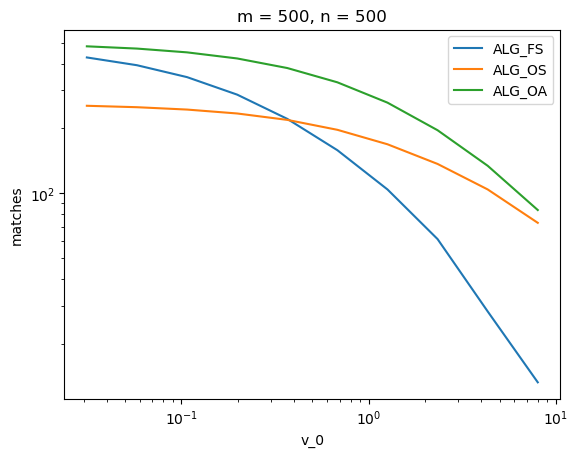

In [19]:
df = pd.read_excel("for graphs.xlsx")

m = 500
n = 500

group_a = [0.5, 1, 2]

group_b_min = 1
group_b_max = 10

scale_range = np.logspace(-3, 5, num=10, base=2)

rep = 50

list_f = [alg_fs, alg_os, alg_oa]
names = ["ALG_FS", "ALG_OS", "ALG_OA"]

group_b = 10

data = simple_data_groups(m,n,group_a,group_b,"exp_tr","unif_tr",[1, 0.707],[0,1,0.707],rep,list_f,scale_range,names,show=True)

v_fs = [sum([row["ALG_FS"] for row in data if row["scale"] == sc]) / rep for sc in scale_range]
v_os = [sum([row["ALG_OS"] for row in data if row["scale"] == sc]) / rep for sc in scale_range]
v_oa = [sum([row["ALG_OA"] for row in data if row["scale"] == sc]) / rep for sc in scale_range]

plt.title(f"m = {m}, n = {n}")
plt.xlabel("v_0")
plt.xscale("log", base=2)
plt.yscale("log", base=2)
plt.ylabel("matches")
#plt.ylim(n)
#plt.plot(range_points, v_naive_fs, label="NVFS")
plt.plot(scale_range ** (-1), v_fs, label="ALG_FS")
plt.plot(scale_range ** (-1), v_os, label="ALG_OS")
plt.plot(scale_range ** (-1), v_oa, label="ALG_OA")


plt.legend()
plt.show()

df_new = pd.DataFrame(data)

df = pd.concat([df, df_new], ignore_index=True)

df.to_excel("for graphs.xlsx", index=False)

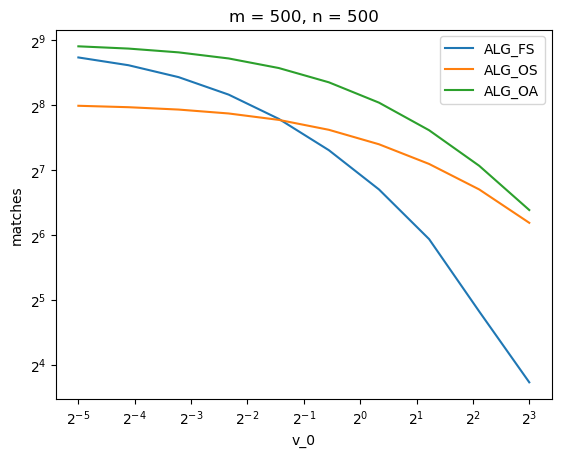

In [20]:
plt.title(f"m = {m}, n = {n}")
plt.xlabel("v_0")
plt.xscale("log", base=2)
plt.yscale("log", base=2)
plt.ylabel("matches")
#plt.ylim(n)
#plt.plot(range_points, v_naive_fs, label="NVFS")
plt.plot(scale_range ** (-1), v_fs, label="ALG_FS")
plt.plot(scale_range ** (-1), v_os, label="ALG_OS")
plt.plot(scale_range ** (-1), v_oa, label="ALG_OA")


plt.legend()
plt.show()

In [23]:
v_fs = []
v_os = []
v_oa = []

In [17]:
group_a = [0.5, 1, 2]

m = 500
n = 500

b_max = 10
b_min = 1
range_group = range(9, 11) # 7,9,10

df = pd.read_excel("for homogeneity.xlsx")

for group_b in range_group:
    t = time.time()
    rep = round(100+100/group_b**2)
    
    d = simple_data(m,n, group_a, group_b, "exp_tr", "unif_tr", [1, 0.707], [0,1, 0.707], rep, [alg_fs, alg_os, alg_oa],\
                    ["ALG_FS", "ALG_OS", "ALG_OA"], [], show = True)
    print(time.time() - t)

    df_new = pd.DataFrame(d)
    df = pd.concat([df, df_new], ignore_index=True)
    
    #v_fs.append(sum([row["ALG_FS"] for row in d]) / rep)
    #v_os.append(sum([row["ALG_OS"] for row in d]) / rep)
    #v_oa.append(sum([row["ALG_OA"] for row in d]) / rep)

df.to_excel("for homogeneity.xlsx", index=False)

number 0 out of 101
Set parameter Username
Set parameter LicenseID to value 2749021
Academic license - for non-commercial use only - expires 2026-12-02
number 1 out of 101
number 2 out of 101
number 3 out of 101
number 4 out of 101
number 5 out of 101
number 6 out of 101
number 7 out of 101
number 8 out of 101
number 9 out of 101
number 10 out of 101
number 11 out of 101
number 12 out of 101
number 13 out of 101
number 14 out of 101
number 15 out of 101
number 16 out of 101
number 17 out of 101
number 18 out of 101
number 19 out of 101
number 20 out of 101
number 21 out of 101
number 22 out of 101
number 23 out of 101
number 24 out of 101
number 25 out of 101
number 26 out of 101
number 27 out of 101
number 28 out of 101
number 29 out of 101
number 30 out of 101
number 31 out of 101
number 32 out of 101
number 33 out of 101
number 34 out of 101
number 35 out of 101
number 36 out of 101
number 37 out of 101
number 38 out of 101
number 39 out of 101
number 40 out of 101
number 41 out of 

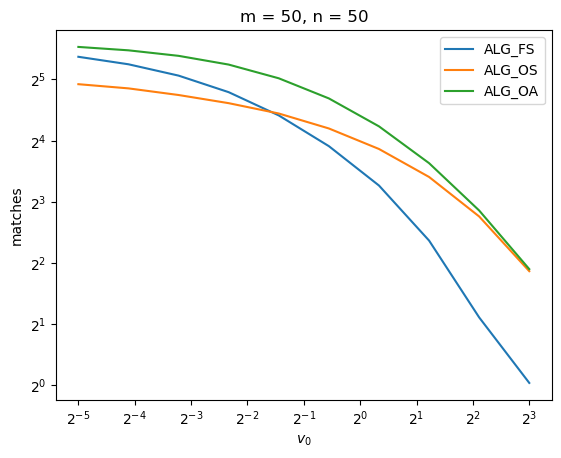

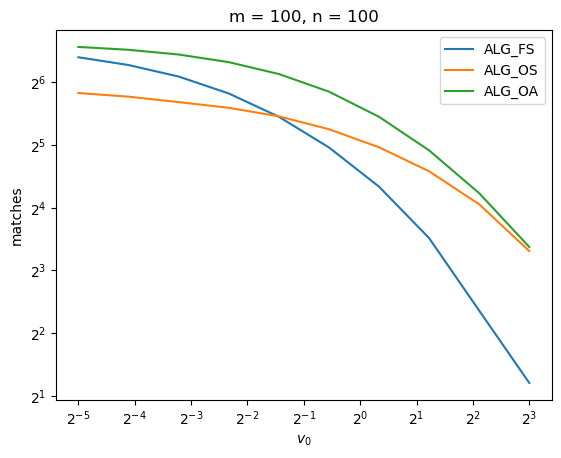

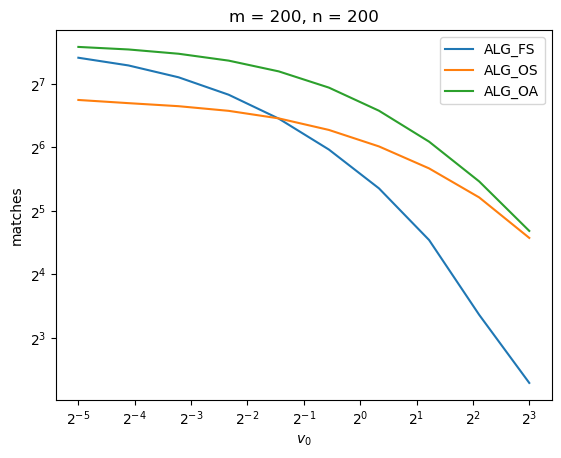

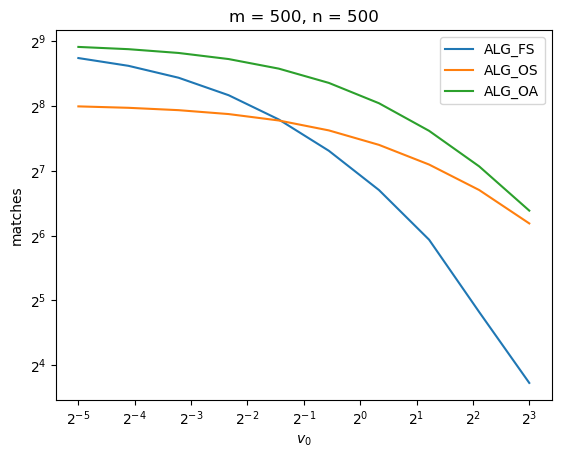

In [30]:
df = pd.read_excel("for graphs.xlsx")

sizes = [50, 100, 200, 500]

scale_range = np.logspace(-3, 5, num=10, base=2)

for s in sizes:
    df2 = df[df["m"] == s]
    df2 = df2[["scale", "ALG_FS", "ALG_OS", "ALG_OA"]].groupby("scale").mean()
    
    plt.title(f"m = {s}, n = {s}")
    plt.xlabel(r"$v_0$")
    plt.xscale("log", base=2)
    plt.yscale("log", base=2)
    plt.ylabel("matches")
    plt.plot(scale_range ** (-1), df2["ALG_FS"], label="ALG_FS")
    plt.plot(scale_range ** (-1), df2["ALG_OS"], label="ALG_OS")
    plt.plot(scale_range ** (-1), df2["ALG_OA"], label="ALG_OA")
    
    plt.legend()
    plt.show()

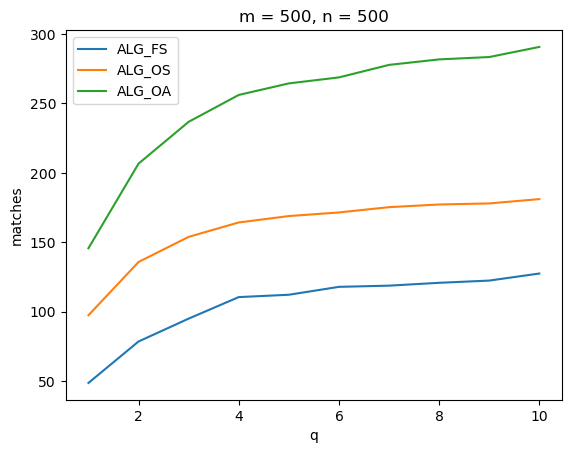

In [32]:
df = pd.read_excel("for homogeneity.xlsx")

q_range = range(1, 11)

s = 500

df2 = df[df["m"] == s]
df2 = df2[["group_b", "ALG_FS", "ALG_OS", "ALG_OA"]].groupby("group_b").mean() #groupby orders automatically

plt.title(f"m = {s}, n = {s}")
plt.xlabel("q")
#plt.xscale("log", base=2)
#plt.yscale("log", base=2)
plt.ylabel("matches")
plt.plot(q_range, df2["ALG_FS"], label="ALG_FS")
plt.plot(q_range, df2["ALG_OS"], label="ALG_OS")
plt.plot(q_range, df2["ALG_OA"], label="ALG_OA")

plt.legend()
plt.show()

In [25]:
    plt.title(f"m = {m}, n = {n}")
    plt.xlabel(r"$v_0$")
    plt.xscale("log", base=2)
    plt.yscale("log", base=2)
    plt.ylabel("matches")
    #plt.ylim(n)
    #plt.plot(range_points, v_naive_fs, label="NVFS")
    plt.plot(scale_range ** (-1), v_fs, label="ALG_FS")
    plt.plot(scale_range ** (-1), v_os, label="ALG_OS")
    plt.plot(scale_range ** (-1), v_oa, label="ALG_OA")
    
    
    plt.legend()
    plt.show()

NameError: name 'range_points' is not defined

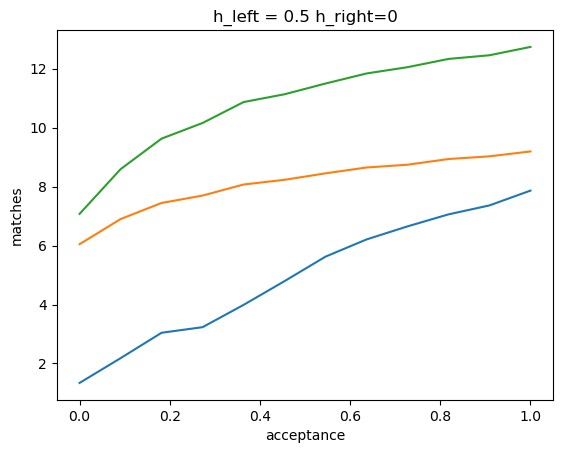

In [108]:
plt.title("h_left = 0.5 h_right=0")
plt.xlabel("acceptance")
plt.ylabel("matches")
plt.plot(range_h, v_fs)
plt.plot(range_h, v_os)
plt.plot(range_h, v_oa)

In [75]:
def approx_xhigh2(b, rep=20, prec=0.02, time=120):
    '''Solve the retained nonconvex high-value relaxation and return the best randomized assignment found.'''
    model = gb.Model('concave relaxation')
    y=[[model.addVar(lb=0,ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name=f'y_{i}{j}') for j in range(b.n)] for i in range(b.m)]
    for i in range(b.m):
        model.addConstr(gb.quicksum(y[i])<=1)

    z=[model.addVar(lb=0, ub=1, vtype=GRB.CONTINUOUS, name=f'z_{j}') for j in range(b.n)]
    for j in range(b.n):
        model.addConstr(z[j]*(1+gb.quicksum([b.right_values[j][i]*y[i][j] for i in range(b.m)]))<=1)

    model.setObjective(gb.quicksum([gb.quicksum([b.right_values[j][i]*y[i][j] for i in range(b.m)])*z[j] for j in range(b.n)]), GRB.MAXIMIZE)
    
    model.setParam('MIPGap', prec)
    #model.setParam('TimeLimit', time)
    model.optimize()

    r=0
    for k in range(rep):
        x=[[False for j in range(b.n)] for i in range(b.m)]
        for i in range(b.m):
            weights=list(accumulate([y[i][j].x for j in range(b.n)]))
            if weights[-1]<=0.:
                continue
            c = random.random()*weights[-1]
            a, d = 0, len(weights)
            m = (a+d)//2
            while d-a > 1:
                if c >= weights[m]:
                    a = m+1
                if c < weights[m]:
                    if c >= weights[m-1]:
                        break
                    d = m
                m = (a+d)//2
                
            x[i][m]=True

        r = max(r,value_fs(b,x))
        
    return r